# Inférence statistique

> Modèles retenus : CatBoost, XGBoost, LightGBM (cible `log1p`) + Stacking OOF  
> Optimisation sur **MAPE** (au lieu de MAE) + feature engineering ciblé sur les petites valeurs.

## Partie A : Imports et configuration

In [33]:
import warnings
warnings.filterwarnings("ignore")

# Manipulation de données
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import json

from sklearn.inspection import permutation_importance

# Optimisation d'hyperparamètres
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


import shap
from sklearn.base import BaseEstimator, RegressorMixin

from sklearn.impute import SimpleImputer
import lime
import joblib

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions/modelisations"))

%load_ext autoreload
%autoreload 2

# On importe les fonctions utiles à la modélisation
from modelisation_finale import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### A1 : Chargement des données

Split **temporel** : train 2020-2022 / val 2023 / test 2024. On entraîne toujours sur le passé et on évalue sur le futur.

In [34]:
# Chargement des données

df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test  = pd.read_csv("../data_finale/featuring/test_featured.csv")
df_en_cours = pd.read_csv("../data_finale/featuring/en_cours_featured.csv")

colonne_cible = "market_value_in_eur"

### A2 : Préparation des jeux de données X / y

In [35]:
data = preparer_donnees(df_train, df_val, df_test, df_en_cours, colonne_cible= colonne_cible)

# Extraction de toutes les variables du dictionnaire
X_train = data["X_train"]
y_train = data["y_train"]
y_train_log = data["y_train_log"]
sample_weights_train = data["sample_weights_train"]

X_val = data["X_val"]
y_val = data["y_val"]
y_val_log = data["y_val_log"]

X_test = data["X_test"]
y_test = data["y_test"]
y_test_log = data["y_test_log"]

X_en_cours = data["X_en_cours"]
y_en_cours = data["y_en_cours"]
y_en_cours_log = data["y_en_cours_log"]

sample_weights_train = data["sample_weights_train"]

X_train : (7404, 146) | X_val : (2431, 146) | X_test : (2295, 146) | X_en_cours : (2283, 146)


## Partie B : Construction et évaluation du modèle final

### B1 : Paramètres fixes

In [36]:
with open("../modelisation/meilleurs_hyperparametres.json", "r") as f:
    params = json.load(f)

RANDOM_STATE = 1308

### B2 : Construction des modèles finaux

In [37]:
modeles_finaux = initialiser_modeles_finaux(params, RANDOM_STATE)

### B3 : Evaluations des premiers modèles

In [38]:
print("Évaluation validation")
resultats_val = {}
for nom, modele in modeles_finaux.items():
    resultats_val[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_val, y_val, w=sample_weights_train)

df_val_res = pd.DataFrame(resultats_val).T.sort_values("MAPE")
print("\nClassement validation (MAPE croissant) :")
print(df_val_res)

Évaluation validation
  Temps d'entraînement XGBoost (log)   :  25.98 s
  XGBoost (log) | MAPE : 42.88% | MAE :    3,027,617 € | R² : 0.8997 | R²adj : 0.8933
  Temps d'entraînement LightGBM (log)  :   8.99 s
  LightGBM (log) | MAPE : 42.40% | MAE :    3,016,168 € | R² : 0.8944 | R²adj : 0.8876
  Temps d'entraînement CatBoost (log)  :  14.26 s
  CatBoost (log) | MAPE : 42.86% | MAE :    3,227,742 € | R² : 0.8777 | R²adj : 0.8699

Classement validation (MAPE croissant) :
                         MAE          RMSE      MAPE        R2  R2 Ajusté  \
LightGBM (log)  3.016168e+06  5.848911e+06  0.423968  0.894378   0.887627   
CatBoost (log)  3.227742e+06  6.294515e+06  0.428610  0.877672   0.869852   
XGBoost (log)   3.027617e+06  5.698516e+06  0.428814  0.899740   0.893332   

                Temps entraînement (s)  
LightGBM (log)                8.994382  
CatBoost (log)               14.259391  
XGBoost (log)                25.980146  


In [39]:
print("Évaluation test")
resultats_test = {}
for nom, modele in modeles_finaux.items():
    resultats_test[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_test, y_test, w=sample_weights_train)

df_test_res = pd.DataFrame(resultats_test).T.sort_values("MAPE")
print("\nClassement test (MAPE croissant) :")
print(df_test_res)

Évaluation test
  Temps d'entraînement XGBoost (log)   :  26.88 s
  XGBoost (log) | MAPE : 40.69% | MAE :    3,231,307 € | R² : 0.8908 | R²adj : 0.8833
  Temps d'entraînement LightGBM (log)  :   8.50 s
  LightGBM (log) | MAPE : 40.17% | MAE :    3,321,653 € | R² : 0.8769 | R²adj : 0.8685
  Temps d'entraînement CatBoost (log)  :  15.32 s
  CatBoost (log) | MAPE : 41.24% | MAE :    3,501,992 € | R² : 0.8772 | R²adj : 0.8688

Classement test (MAPE croissant) :
                         MAE          RMSE      MAPE        R2  R2 Ajusté  \
LightGBM (log)  3.321653e+06  6.554227e+06  0.401748  0.876911   0.868544   
XGBoost (log)   3.231307e+06  6.174568e+06  0.406884  0.890758   0.883332   
CatBoost (log)  3.501992e+06  6.547836e+06  0.412371  0.877150   0.868800   

                Temps entraînement (s)  
LightGBM (log)                8.497887  
XGBoost (log)                26.878144  
CatBoost (log)               15.315797  


In [40]:
print("Évaluation année en cours")
resultats_en_cours = {}
for nom, modele in modeles_finaux.items():
    resultats_en_cours[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_en_cours, y_en_cours, w=sample_weights_train)

df_en_cours_res = pd.DataFrame(resultats_en_cours).T.sort_values("MAPE")
print("\nClassement en cours (MAPE croissant) :")
print(df_en_cours_res)

Évaluation année en cours
  Temps d'entraînement XGBoost (log)   :  27.05 s
  XGBoost (log) | MAPE : 39.21% | MAE :    3,964,153 € | R² : 0.8113 | R²adj : 0.7984
  Temps d'entraînement LightGBM (log)  :   8.57 s
  LightGBM (log) | MAPE : 39.46% | MAE :    4,061,924 € | R² : 0.7951 | R²adj : 0.7811
  Temps d'entraînement CatBoost (log)  :   9.83 s
  CatBoost (log) | MAPE : 41.31% | MAE :    4,447,267 € | R² : 0.7755 | R²adj : 0.7601

Classement en cours (MAPE croissant) :
                         MAE          RMSE      MAPE        R2  R2 Ajusté  \
XGBoost (log)   3.964153e+06  8.392413e+06  0.392097  0.811328   0.798432   
LightGBM (log)  4.061924e+06  8.746197e+06  0.394592  0.795085   0.781079   
CatBoost (log)  4.447267e+06  9.155607e+06  0.413056  0.775452   0.760104   

                Temps entraînement (s)  
XGBoost (log)                27.054302  
LightGBM (log)                8.567127  
CatBoost (log)                9.833603  


### B4 : Stacking OOF

Le Stacking OOF combine les 3 meilleurs modèles boosting via un méta-modèle linéaire à coefficients positifs (combinaison convexe).

Les prédictions OOF garantissent que chaque exemple du train reçoit une prédiction issue d'un modèle qui ne l'a jamais vu, contrairement à un split fixe qui biaiserait les poids du méta-modèle.

#### B4.1 : Génération des prédictions OOF et construction du méta-modèle

In [ ]:
base_models = ["XGBoost (log)", "LightGBM (log)", "CatBoost (log)"]

# Charger le JSON
with open("../modelisation/poids_stacking.json", "r") as f:
    meta_config = json.load(f)

# On reconstruit notre méta-modèle
meta = reconstruire_meta_modele(meta_config, base_models)

# Dictionnaire contenant le méta-modèle et ses métadonnées
parametres = {
    "meta_model": meta,
    "base_models": base_models,
    "meta_config": meta_config,
}

Méta-modèle reconstruit avec succès !
Poids : {'XGBoost (log)': np.float64(0.189), 'LightGBM (log)': np.float64(0.382), 'CatBoost (log)': np.float64(0.486)}
Intercept : 363,806.92 €
Méta-modèle sauvegardé


#### B4.2 : Entraînement et évaluations du modèle final

In [42]:
resultats = entrainer_et_predire_stacking(
    base_models, modeles_finaux, meta,
    X_train, y_train_log, X_val, y_val_log, X_test, X_en_cours,
    sample_weights_train
)


Entraînement des modèles de base...
  XGBoost (log) : entraîné en 29.63 s
  LightGBM (log) : entraîné en 9.48 s
  CatBoost (log) : entraîné en 14.99 s

Prédictions du Stacking calculées avec succès.

Temps total Stacking OOF (entraînement + prédictions) : 55.46 s
    dont XGBoost (log)   : 29.63 s
    dont LightGBM (log)  : 9.48 s
    dont CatBoost (log)  : 14.99 s


#### B4.3 : Analyse d'erreur par tranche de valeur, par âge puis par poste

On décompose l'erreur du meilleur modèle par tranche de valeur marchande pour identifier où le modèle peine le plus.

In [43]:
# Exemple d'appel avec les prédictions finales du Stacking
synthese = analyser_erreurs_par_tranches(
    y_reel=y_test, y_pred=resultats["pred_test_stack"]
)

         n_joueurs  valeur_moyenne           MAE    MAPE_pct  \
tranche                                                        
<1M€           261    6.704023e+05  8.685371e+05  199.876262   
1-5M€          814    2.978010e+06  1.135322e+06   40.695950   
5-20M€         795    1.164088e+07  3.551016e+06   31.748925   
20-50M€        343    3.234111e+07  6.971356e+06   22.045166   
>50M€           82    8.414634e+07  1.629820e+07   19.349029   

         % du total joueurs  % de l'erreur absolue totale  
tranche                                                    
<1M€              11.372549                      2.943419  
1-5M€             35.468410                     11.999601  
5-20M€            34.640523                     36.655825  
20-50M€           14.945534                     31.048071  
>50M€              3.572985                     17.353083  


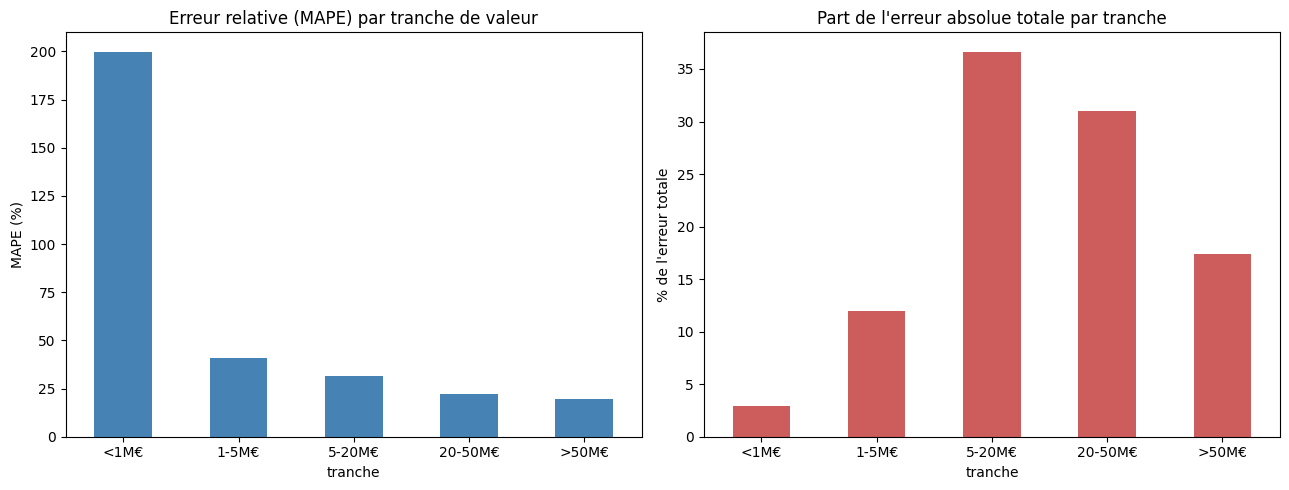

In [44]:
afficher_graphiques_analyse_erreurs(
    y_reel=y_test,
    y_pred=resultats["pred_test_stack"],
    synthese_tranches=synthese,
    random_state=RANDOM_STATE
)

             n_joueurs  age_moyen  valeur_moyenne           MAE    MAPE_pct  \
tranche_age                                                                   
<21 ans            295  18.949153    1.191373e+07  4.028615e+06  121.138348   
21-24 ans          691  22.609262    1.730637e+07  4.368863e+06   46.480062   
25-28 ans          709  26.428773    1.552327e+07  3.423990e+06   33.845221   
29-32 ans          444  30.360360    6.756757e+06  2.135210e+06   42.157561   
33+ ans            156  34.519231    2.354647e+06  7.599854e+05   58.429236   

             % du total joueurs  % de l'erreur absolue totale  
tranche_age                                                    
<21 ans               12.854031                     15.431247  
21-24 ans             30.108932                     39.198526  
25-28 ans             30.893246                     31.521139  
29-32 ans             19.346405                     12.309683  
33+ ans                6.797386                      1.539406 

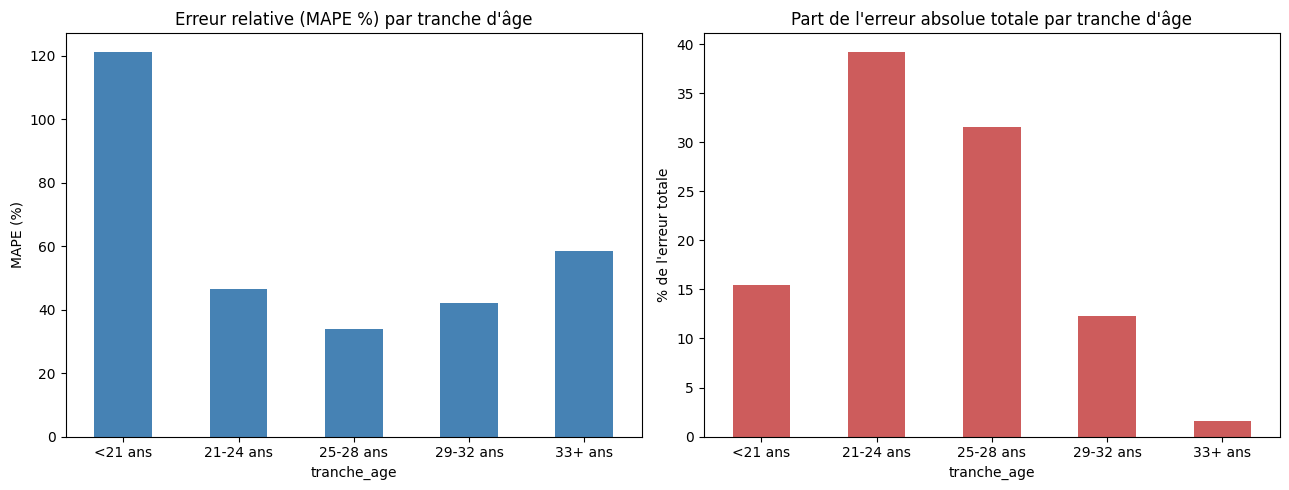

In [45]:
synthese_age = analyser_et_afficher_erreurs_par_age(
    y_reel=y_test,
    y_pred=resultats["pred_test_stack"],
    ages=df_test["age"]
)

            n_joueurs  valeur_moyenne           MAE   MAPE_pct  \
position                                                         
Defender          822    1.115675e+07  2.953220e+06  47.772512   
Midfield          664    1.444394e+07  3.683295e+06  47.915873   
Goalkeeper        175    7.898857e+06  2.334357e+06  58.535002   
Attack            634    1.530386e+07  3.816654e+06  60.495182   

            % du total joueurs  % de l'erreur absolue totale  
position                                                      
Defender             35.816993                     31.520339  
Midfield             28.932462                     31.756143  
Goalkeeper            7.625272                      5.304305  
Attack               27.625272                     31.419213  


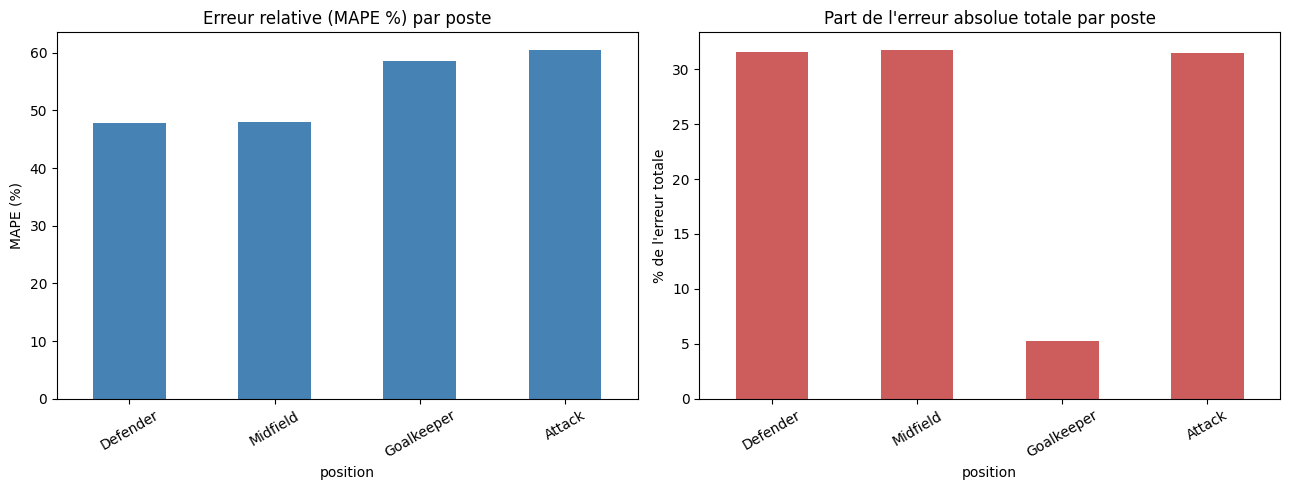

In [46]:
synthese_poste = analyser_et_afficher_erreurs_par_poste(
    y_reel=y_test,
    y_pred=resultats["pred_test_stack"],
    positions=df_test["position"],
    seuil_min_joueurs=5
)

### B5 : Sauvegarde du pipeline pour l'explicabilité (notebook 10)

On sauvegarde dans un seul fichier tout ce dont le notebook 10 a besoin : les jeux de données (X/y/df) et les modèles finaux déjà entraînés (`modeles_finaux`, `meta`).

In [ ]:
pipeline_explicabilite = {
    "X_train": X_train, "X_val": X_val, "X_test": X_test, "X_en_cours": X_en_cours,
    "y_train": y_train, "y_val": y_val, "y_test": y_test, "y_en_cours": y_en_cours,
    "df_train": df_train, "df_val": df_val, "df_test": df_test, "df_en_cours": df_en_cours,
    "modeles_finaux": modeles_finaux,
    "meta": meta,
    "colonne_cible": colonne_cible,
    "RANDOM_STATE": RANDOM_STATE,
}

joblib.dump(pipeline_explicabilite, "../modelisation/pipeline_explicabilite.pkl")
print("Pipeline sauvegardé -> ../modelisation/pipeline_explicabilite.pkl")

Pipeline sauvegardé -> ../modelisation/pipeline_explicabilite.pkl
